# Proyecto Final - Machine Learning sobre Datos Brutos
## Prediccion de Precio por Transaccion · Ropa Medellin
---
> **Inteligencia Artificial: De los Fundamentos a la Implementacion**

**Contexto:** Medellin es la **Capital de la Moda de America Latina**. Eres el cientific@
de datos de una cadena de moda con presencia en 6 centros comerciales de la
ciudad debes **predecir cuantas unidades por categoria se venderan
en los proximos 7 dias** para tomar decisiones de inventario y liquidacion.

**Objetivo:** Predecir el `precio_final` (COP) de **cada transaccion individual** a partir de sus caracteristicas: categoria, talla, color, descuento, temporada, hora y dia.

```
EVENTOS CALENDARIOS CRiTICOS EN MODA
======================================
Enero       Liquidacion post-Navidad   (+90% volumen, hasta 70% descuento)
Mayo        Dia de la Madre            (+150% trafico)
Julio       Liquidacion mid-year       (hasta 60% descuento)
Septiembre  Amor y Amistad             (+80% semana previa al 14/sep)
Diciembre   Temporada Navidad          (+60% en todo el mes)
Festivos    CC reciben +70% vs normal
Finde       2-3x el trafico de semana
```

---

## Indice

| Fase | Contenido |
|------|-----------|
| **FASE 0** | Preparacion del entorno e imports |
| **FASE 1** | Carga y optimizacion de memoria (3.7M filas) |
| **FASE 2** | Analisis Exploratorio (EDA) |
| **FASE 3** | Feature Engineering + Codificacion |
| **FASE 4** | Split temporal + definicion del target |
| **FASE 5** | arbol de Decision (baseline + visualizacion) |
| **FASE 6** | Modelos Ensemble con CV (RF · XGBoost · LightGBM) |
| **FASE 7** | Optimizacion de Hiperparametros con Optuna |
| **FASE 8** | Feature Importance |
| **FASE 9** | Analisis de Tiempos - Trade-off rendimiento vs velocidad |
| **FASE 10** | Stacking con Red Neuronal |
| **FASE 11** | Sistema de Decision de Precios |
| **FASE 12** | Tabla Comparativa Final |
| **FASE 13** | Reflexion y Conclusiones |

6 CC · 36 referencias · 2021-2023 · ~3 millones de items vendidos

## FASE 0 - Preparacion del Entorno

In [2]:
# --- Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, os, time, joblib
from datetime import datetime
from pathlib import Path

# --- Sklearn
from sklearn.model_selection  import cross_val_score, KFold
from sklearn.linear_model     import Ridge
from sklearn.tree             import DecisionTreeRegressor, plot_tree, export_text
from sklearn.ensemble         import RandomForestRegressor
from sklearn.preprocessing    import LabelEncoder, StandardScaler
from sklearn.metrics          import mean_squared_error, r2_score, mean_absolute_error

# --- Boosting
import xgboost  as xgb
import lightgbm as lgb

# --- Optimizacion bayesiana
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# --- Deep Learning
import tensorflow as tf
from tensorflow       import keras
from tensorflow.keras import layers, callbacks
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# --- Estilo global
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size']      = 11
PALETA = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0', '#F44336', '#00BCD4']
sns.set_palette(PALETA)
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# --- Rutas ---
RUTA_DATASET = Path('ropa_medellin.csv')
for alt in ['ropa/ropa_medellin.csv', '../ropa/ropa_medellin.csv',
            '/home/claude/ropa/ropa_medellin.csv']:
    if not RUTA_DATASET.exists() and Path(alt).exists():
        RUTA_DATASET = Path(alt)

# --- Extraccion ZIP ---
if not RUTA_DATASET.exists():
    import zipfile
    zip_candidatos = ['ropa.zip', '../ropa.zip']
    for zc in zip_candidatos:
        if Path(zc).exists():
            print(f"CSV no encontrado. Extrayendo {zc}...")
            with zipfile.ZipFile(zc) as zf:
                zf.extractall('.')
            print("Extraccion completa")
            break
    # Re-buscar luego de extraer
    for alt in ['ropa/ropa_medellin.csv', 'ropa_medellin.csv']:
        if Path(alt).exists():
            RUTA_DATASET = Path(alt)
            break
    if not RUTA_DATASET.exists():
        raise FileNotFoundError(
            "No se encontro ropa_medellin.csv. Coloca ropa.zip en la misma carpeta que este notebook."
        )

RUTA_CKPT = Path('output/checkpoints')
RUTA_IMGS = Path('output/imgs')
RUTA_CKPT.mkdir(parents=True, exist_ok=True)
RUTA_IMGS.mkdir(parents=True, exist_ok=True)

print(f"Dataset    : {RUTA_DATASET}")
print(f"Checkpoints: {RUTA_CKPT}")
print(f"Imagenes   : {RUTA_IMGS}")
print(f"TF {tf.__version__} | LGB {lgb.__version__} | XGB {xgb.__version__}")

Dataset    : ropa_medellin.csv
Checkpoints: output/checkpoints
Imagenes   : output/imgs
TF 2.21.0 | LGB 4.6.0 | XGB 3.2.0


## FASE 1 - Carga y Optimizacion de Memoria

### ¿Por que optimizar los tipos de datos?

El dataset tiene **3.7 millones de filas**. Sin optimizacion, pandas asigna `int64` (8 bytes) a cada columna numerica y `object` a las de texto. Con dtypes optimizados:

| Tipo original | Tipo optimizado | Ahorro |
|---------------|----------------|--------|
| `int64` -> columnas 0-127 | `int8` | 8x menos RAM |
| `object` -> categorias | `category` | ~80% menos RAM |
| `int64` -> precios | `int32` | 2x menos RAM |

El resultado: **~156 MB en lugar de ~1 GB**.

In [3]:
# --- Diccionario de dtypes optimizados ---
DTYPES = {
    'venta_id'        : 'int32',
    'hora'            : 'int8',
    'estrato'         : 'int8',
    'tienda_id'       : 'category',
    'nombre_tienda'   : 'category',
    'centro_comercial': 'category',
    'barrio'          : 'category',
    'producto_id'     : 'category',
    'nombre_producto' : 'category',
    'categoria'       : 'category',
    'genero_objetivo' : 'category',
    'talla'           : 'category',
    'color'           : 'category',
    'metodo_pago'     : 'category',
    'cantidad'        : 'int8',
    'precio_unitario' : 'int32',
    'descuento_pct'   : 'int8',
    'precio_final'    : 'int32',
    'es_liquidacion'  : 'int8',
    'liq_enero'       : 'int8',
    'liq_julio'       : 'int8',
    'es_dia_madre'    : 'int8',
    'es_amor_amistad' : 'int8',
    'es_dia_padre'    : 'int8',
    'es_feria_flores' : 'int8',
    'es_diciembre'    : 'int8',
    'es_festivo'      : 'int8',
}

print("Cargando Dataset...")
t0 = datetime.now()
df = pd.read_csv(RUTA_DATASET, parse_dates=['fecha'], dtype=DTYPES)
elapsed = (datetime.now() - t0).seconds

print(f"Listo en {elapsed}s")
print(f"- Shape  : {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"- Memoria: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"- Periodo: {df['fecha'].min().date()} -> {df['fecha'].max().date()}")

# --- Confirmarcion de las 3.7M filas ---
if df.shape[0] < 3_000_000:
    print(f"\nADVERTENCIA: Solo se cargaron {df.shape[0]:,} filas.")
    print("   Se esperan ~3.7 millones. Verifica que el archivo correcto este en la ruta:")
    print(f"   {RUTA_DATASET}")
else:
    print(f"Validacion OK: {df.shape[0]:,} filas cargadas correctamente.")

df.head(3)

Cargando Dataset...
Listo en 4s
- Shape  : 3,724,486 filas x 28 columnas
- Memoria: 156.3 MB
- Periodo: 2021-01-01 -> 2023-12-31
Validacion OK: 3,724,486 filas cargadas correctamente.


,venta_id,fecha,hora,tienda_id,nombre_tienda,centro_comercial,barrio,estrato,producto_id,nombre_producto,...,metodo_pago,es_liquidacion,liq_enero,liq_julio,es_dia_madre,es_amor_amistad,es_dia_padre,es_feria_flores,es_diciembre,es_festivo
0,1,2021-01-01,19,R01,Coleccion El Tesoro,El Tesoro,El Poblado,5,J003,Cardigan tejido,...,Debito,1,1,0,0,0,0,0,0,1
1,2,2021-01-01,19,R01,Coleccion El Tesoro,El Tesoro,El Poblado,5,C002,Blusa estampada mujer,...,Credito,1,1,0,0,0,0,0,0,1
2,3,2021-01-01,18,R01,Coleccion El Tesoro,El Tesoro,El Poblado,5,D003,Chaqueta rompevientos,...,Credito,1,1,0,0,0,0,0,0,1


In [4]:
# --- Inspeccion inicial ---
print("TIPOS DE DATOS")
print("=" * 35)
print(df.dtypes)
print()
print("VALORES NULOS")
print("=" * 35)

nulos = df.isnull().sum()

print(nulos[nulos > 0] if nulos.sum() > 0 else "Sin valores nulos")
print()
print("ESTADISTICA DESCRIPTIVA")
print("=" * 35)

df[['hora','estrato','cantidad','precio_unitario','descuento_pct','precio_final']].describe().round(0)

TIPOS DE DATOS
venta_id                     int32
fecha               datetime64[us]
hora                          int8
tienda_id                 category
nombre_tienda             category
centro_comercial          category
barrio                    category
estrato                       int8
producto_id               category
nombre_producto           category
categoria                 category
genero_objetivo           category
talla                     category
color                     category
cantidad                      int8
precio_unitario              int32
descuento_pct                 int8
precio_final                 int32
metodo_pago               category
es_liquidacion                int8
liq_enero                     int8
liq_julio                     int8
es_dia_madre                  int8
es_amor_amistad               int8
es_dia_padre                  int8
es_feria_flores               int8
es_diciembre                  int8
es_festivo                    int8
dtype

,hora,estrato,cantidad,precio_unitario,descuento_pct,precio_final
count,3724486.0,3724486.0,3724486.0,3724486.0,3724486.0,3724486.0
mean,16.0,3.0,2.0,91939.0,18.0,118003.0
std,3.0,1.0,1.0,63567.0,21.0,112971.0
min,10.0,2.0,1.0,20000.0,0.0,6000.0
25%,14.0,2.0,1.0,51000.0,0.0,49000.0
50%,16.0,3.0,1.0,74000.0,10.0,84000.0
75%,18.0,4.0,2.0,111000.0,30.0,146000.0
max,21.0,5.0,3.0,521000.0,70.0,1560000.0


In [5]:
# --- Analisis de columnas categoricas ---
for col in ['categoria', 'talla', 'color', 'genero_objetivo', 'metodo_pago', 'centro_comercial']:
    print(f"\n{col} ({df[col].nunique()} valores unicos):")
    print(df[col].value_counts().to_string())
    print("-" * 40)


categoria (8 valores unicos):
categoria
Pantalones          728063
Camisetas y Tops    689122
Ropa Interior       501811
Accesorios          425152
Calzado             378508
Vestidos            378011
Chaquetas           339450
Deportiva           284369
----------------------------------------

talla (6 valores unicos):
talla
XXL    622306
M      621356
XL     620451
L      620447
S      620416
XS     619510
----------------------------------------

color (10 valores unicos):
color
Gris       372965
Negro      372942
Rojo       372804
Blanco     372775
Rosado     372407
Verde      372255
Morado     372237
Cafe       372107
Naranja    372055
Azul       371939
----------------------------------------

genero_objetivo (3 valores unicos):
genero_objetivo
M    2002792
H     899816
U     821878
----------------------------------------

metodo_pago (3 valores unicos):
metodo_pago
Debito      1514336
Efectivo    1161415
Credito     1048735
----------------------------------------

centro_co

## FASE 2 - Analisis Exploratorio de Datos (EDA)

**Referencia:** Clase5_Validacion_ML

Analizamos el **target** (`precio_final`) y los patrones clave del negocio.

In [6]:
# --- 2.1 Estadisticas del target ---
print("TARGET: precio_final (COP por transaccion)")
print("=" * 45)
print(f"  Media    : ${df['precio_final'].mean():>12,.0f}")
print(f"  Mediana  : ${df['precio_final'].median():>12,.0f}")
print(f"  Min      : ${df['precio_final'].min():>12,.0f}")
print(f"  Max      : ${df['precio_final'].max():>12,.0f}")
print(f"  Std      : ${df['precio_final'].std():>12,.0f}")
print()

# Ingresos por categoria
print("Precio promedio por categoria (COP):")
print(df.groupby('categoria')['precio_final'].mean().sort_values(ascending=False).apply(lambda x: f'${x:,.0f}').to_string())

TARGET: precio_final (COP por transaccion)
  Media    : $     118,003
  Mediana  : $      84,000
  Min      : $       6,000
  Max      : $   1,560,000
  Std      : $     112,971

Precio promedio por categoria (COP):
categoria
Chaquetas           $217,971
Calzado             $191,979
Deportiva           $147,132
Vestidos            $130,601
Pantalones          $124,314
Accesorios           $76,508
Camisetas y Tops     $67,382
Ropa Interior        $64,096


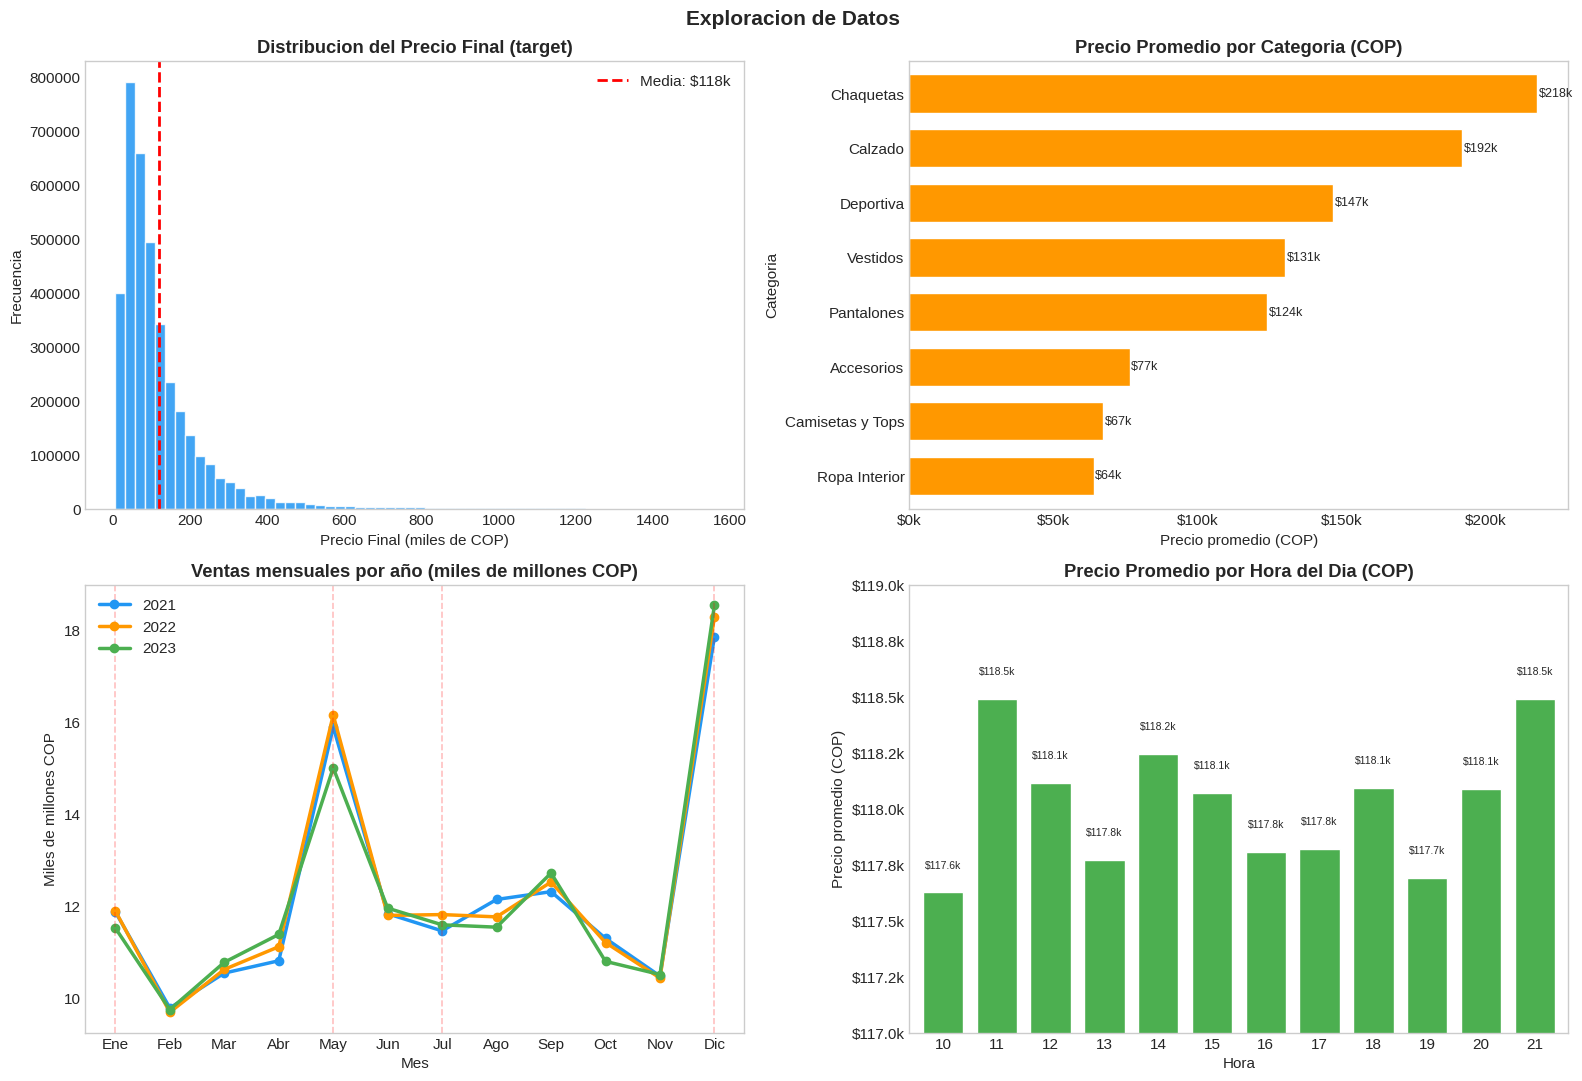

Guardada: output/imgs/eda_overview.png


In [ ]:
# --- 2.2 Graficas EDA ---
ventas_mes = df.groupby(
    [df['fecha'].dt.year.rename('anio'), df['fecha'].dt.month.rename('mes')]
)['precio_final'].sum().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Exploracion de Datos', fontsize=15, fontweight='bold')

# 1 - Distribucion del precio_final (target)
ax = axes[0, 0]
ax.hist(df['precio_final'] / 1000, bins=60, color='#2196F3', edgecolor='white', alpha=0.85)
ax.set_title('Distribucion del Precio Final (target)', fontweight='bold')
ax.set_xlabel('Precio Final (miles de COP)')
ax.set_ylabel('Frecuencia')
ax.axvline(df['precio_final'].mean() / 1000, color='red', ls='--', lw=2,
           label=f'Media: ${df["precio_final"].mean()/1000:.0f}k')
ax.legend()
ax.grid(False)

# 2 - Precio promedio por categoria
ax = axes[0, 1]
precio_cat = df.groupby('categoria')['precio_final'].mean().sort_values()
precio_cat.plot(kind='barh', ax=ax, color='#FF9800', edgecolor='white', width=0.7)
ax.set_title('Precio Promedio por Categoria (COP)', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.set_ylabel('Categoria')
ax.set_xlabel('Precio promedio (COP)')
for bar in ax.patches:
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height() / 2,
            f'${bar.get_width()/1000:.0f}k', va='center', fontsize=9)
ax.grid(False)

# 3 - Ventas mensuales
ax = axes[1, 0]
colores_anio = {2021: '#2196F3', 2022: '#FF9800', 2023: '#4CAF50'}
for anio, g in ventas_mes.groupby('anio'):
    ax.plot(g['mes'], g['precio_final'] / 1e9, marker='o', lw=2.5,
            label=str(anio), color=colores_anio.get(anio, 'gray'))
ax.set_title('Ventas mensuales por año (miles de millones COP)', fontweight='bold')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'])
ax.set_xlabel('Mes')
ax.set_ylabel('Miles de millones COP')
ax.legend()
for mes_pico in [1, 5, 7, 12]:
    ax.axvline(mes_pico, color='red', alpha=0.25, ls='--', lw=1.2)
ax.grid(False)

# 4 - Precio promedio por hora del dia
ax = axes[1, 1]
precio_hora = df.groupby('hora')['precio_final'].mean()
precio_hora.plot(kind='bar', ax=ax, color='#4CAF50', edgecolor='white', rot=0, width=0.75)
ax.set_title('Precio Promedio por Hora del Dia (COP)', fontweight='bold')
ax.set_xlabel('Hora')
ax.set_ylabel('Precio promedio (COP)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.1f}k'))
ax.set_ylim(117000, 119000)
ax.grid(False)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 100,
            f'${bar.get_height()/1000:.1f}k',
            ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
plt.savefig(RUTA_IMGS / 'eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print("Guardada: output/imgs/eda_overview.png")

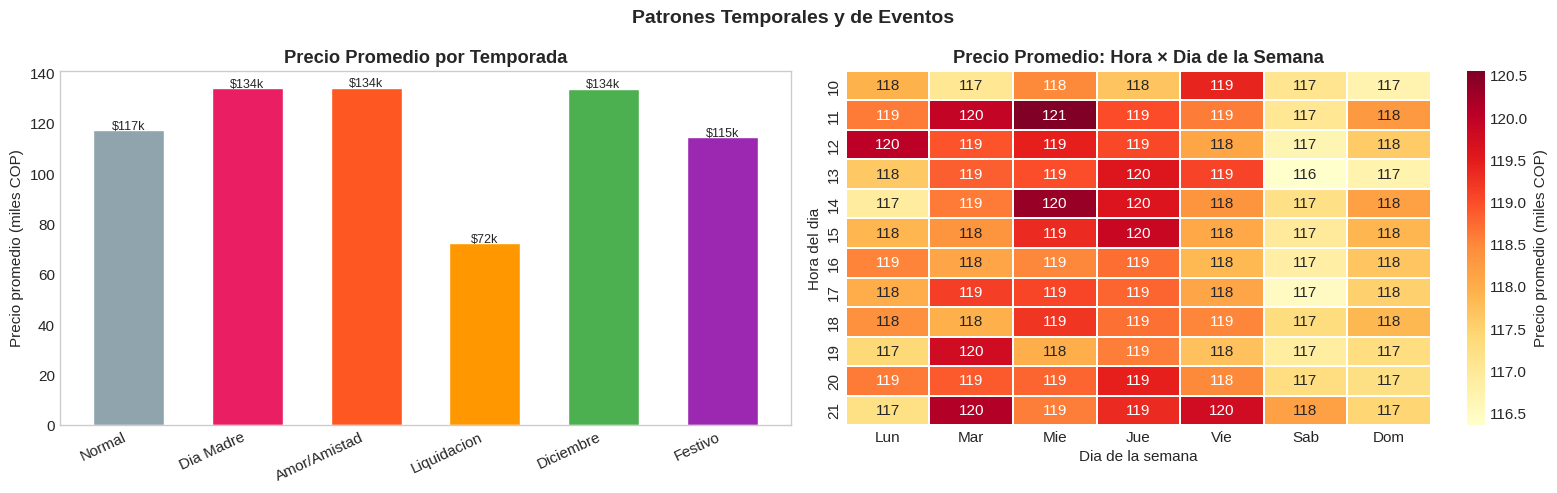

Guardada: output/imgs/eda_tiempo.png


In [ ]:
# --- 2.3 Impacto de eventos especiales sobre el precio ---
eventos = {
    'Normal'      : df[df['es_dia_madre']   == 0]['precio_final'].mean(),
    'Dia Madre'   : df[df['es_dia_madre']   == 1]['precio_final'].mean(),
    'Amor/Amistad': df[df['es_amor_amistad']== 1]['precio_final'].mean(),
    'Liquidacion' : df[df['es_liquidacion'] == 1]['precio_final'].mean(),
    'Diciembre'   : df[df['es_diciembre']   == 1]['precio_final'].mean(),
    'Festivo'     : df[df['es_festivo']     == 1]['precio_final'].mean(),
}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Patrones Temporales y de Eventos', fontsize=14, fontweight='bold')

# Eventos
pal_ev = ['#90A4AE','#E91E63','#FF5722','#FF9800','#4CAF50','#9C27B0']
bars = axes[0].bar(eventos.keys(), [v/1000 for v in eventos.values()],
                   color=pal_ev, edgecolor='white', width=0.6)
axes[0].set_title('Precio Promedio por Temporada', fontweight='bold')
axes[0].set_xticks(range(len(eventos)))
axes[0].set_xticklabels(list(eventos.keys()), rotation=25, ha='right')
axes[0].set_ylabel('Precio promedio (miles COP)')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'${bar.get_height():.0f}k', ha='center', fontsize=9)
axes[0].grid(False)

# Heatmap hora × dia semana
# Se evita df.copy() de 3.7M filas -> se cacula dia de la semana directamente
pivot = df.assign(dia_semana=df['fecha'].dt.dayofweek).pivot_table(
    values='precio_final', index='hora', columns='dia_semana', aggfunc='mean'
) / 1000
pivot.columns = ['Lun','Mar','Mie','Jue','Vie','Sab','Dom']
sns.heatmap(pivot, ax=axes[1], cmap='YlOrRd', fmt='.0f', annot=True,
            linewidths=0.3, cbar_kws={'label': 'Precio promedio (miles COP)'})
axes[1].set_title('Precio Promedio: Hora × Dia de la Semana', fontweight='bold')
axes[1].set_xlabel('Dia de la semana')
axes[1].set_ylabel('Hora del dia')

plt.tight_layout()
plt.savefig(RUTA_IMGS / 'eda_tiempo.png', dpi=150, bbox_inches='tight')
plt.show()

print("Guardada: output/imgs/eda_tiempo.png")

## FASE 3 - Feature Engineering + Codificacion

**Referencia:** Arbol_Decision

A diferencia de la version agregada, aqui usamos **todas las columnas de cada transaccion individual**:
las caracteristicas del producto (talla, color, categoria), del cliente (estrato, metodo de pago),
del momento (hora, dia, temporada) y del descuento aplicado.

In [ ]:
# --- 3.1 Features temporales ---
df['anio']              = df['fecha'].dt.year.astype('int16')
df['mes']               = df['fecha'].dt.month.astype('int8')
df['dia_semana']        = df['fecha'].dt.dayofweek.astype('int8')
df['trimestre']         = df['fecha'].dt.quarter.astype('int8')
df['es_finde']          = (df['dia_semana'] >= 5).astype('int8')
df['dias_desde_inicio'] = (df['fecha'] - df['fecha'].min()).dt.days.astype('int16')

# --- 3.2 Temporada de moda ---
condiciones = [
    df['es_liquidacion'] == 1,
    (df['es_dia_madre'] == 1) | (df['es_amor_amistad'] == 1) | (df['es_dia_padre'] == 1),
    df['es_diciembre'] == 1,
]
df['temporada_moda'] = np.select(condiciones, [1, 2, 3], default=0).astype('int8')

# --- 3.3 Nivel de descuento ---
df['nivel_descuento'] = pd.cut(
    df['descuento_pct'].astype(int),
    bins=[-1, 0, 15, 29, 100],
    labels=[0, 1, 2, 3]
).astype('int8')

# --- 3.4 Codificacion de categoricas con LabelEncoder ---
le = LabelEncoder()
cat_cols = {
    'categoria'       : 'categoria_enc',
    'talla'           : 'talla_enc',
    'color'           : 'color_enc',
    'genero_objetivo' : 'genero_enc',
    'metodo_pago'     : 'metodo_enc',
    'tienda_id'       : 'tienda_enc',
    'centro_comercial': 'cc_enc',
}

for col_orig, col_enc in cat_cols.items():
    df[col_enc] = le.fit_transform(df[col_orig].astype(str))
    print(f"{col_orig}: {df[col_orig].nunique()} categorias | {col_enc}")

print(f"\nFeature Engineering completo")
print(f"- Total columnas ahora: {df.shape[1]}")

categoria: 8 categorias | categoria_enc
talla: 6 categorias | talla_enc
color: 10 categorias | color_enc
genero_objetivo: 3 categorias | genero_enc
metodo_pago: 3 categorias | metodo_enc
tienda_id: 6 categorias | tienda_enc
centro_comercial: 6 categorias | cc_enc

Feature Engineering completo
- Total columnas ahora: 43


## FASE 4 - Target y Split Temporal

**Target:** `precio_final` - el precio en COP de cada transaccion individual.

**Split temporal (80/20):** Usamos las fechas mas recientes como test.
Esto simula el escenario real: el modelo aprende del pasado y predice el futuro.

> **No usamos split aleatorio** porque introduciria *data leakage*:
> el modelo veria datos del futuro durante el entrenamiento.

In [31]:
# --- Definir features y target ---
FEATURES = [
    # Temporales
    'anio', 'mes', 'dia_semana', 'trimestre', 'es_finde',
    'dias_desde_inicio', 'hora',
    # Producto
    'categoria_enc', 'talla_enc', 'color_enc', 'genero_enc',
    'precio_unitario', 'cantidad',
    # Tienda
    'tienda_enc', 'cc_enc', 'estrato',
    # Transaccion
    'metodo_enc', 'descuento_pct', 'nivel_descuento',
    # Eventos
    'es_liquidacion', 'es_dia_madre', 'es_amor_amistad', 'es_dia_padre',
    'es_feria_flores', 'es_diciembre', 'es_festivo',
    'temporada_moda',
]
TARGET = 'precio_final'

X = df[FEATURES]
y = df[TARGET].astype('float32')

# --- Split temporal 80/20 por fecha ---
fecha_corte = df['fecha'].quantile(0.80)
mask_train  = df['fecha'] <= fecha_corte
X_train, X_test = X[mask_train].copy(), X[~mask_train].copy()
y_train, y_test = y[mask_train].copy(), y[~mask_train].copy()

print(f"TARGET          : {TARGET} (COP por transaccion)")
print(f"Features        : {len(FEATURES)}")
print(f"Corte temporal  : {fecha_corte.date()}")
print(f"Train           : {len(X_train):>10,} filas  ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test            : {len(X_test):>10,} filas  ({len(X_test)/len(X)*100:.0f}%)")
print(f"\nTarget - Media : ${y_train.mean():>12,.0f}")
print(f"Target - Rango : [${y_train.min():,.0f} - ${y_train.max():,.0f}]")

TARGET          : precio_final (COP por transaccion)
Features        : 27
Corte temporal  : 2023-05-25
Train           :  2,980,682 filas  (80%)
Test            :    743,804 filas  (20%)

Target - Media : $     117,329
Target - Rango : [$6,000 - $1,560,000]


In [32]:
# --- Funcion de evaluacion ---
def evaluar_modelo(y_true, y_pred, nombre='Modelo'):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    print(f'\n{"="*55}')
    print(f'  {nombre}')
    print(f'{"="*55}')
    print(f'- R²   : {r2:.4f}  (1.0 = prediccion perfecta)')
    print(f'- RMSE : ${rmse:>12,.0f} COP')
    print(f'- MAE  : ${mae:>12,.0f} COP')
    return {'R2': r2, 'RMSE': rmse, 'MAE': mae}

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
RESULTADOS = {}

print("Funcion evaluar_modelo() y KFold(5) configurados")

Funcion evaluar_modelo() y KFold(5) configurados


## FASE 5 - arbol de Decision (Baseline + Visualizacion)

**Referencia:** Arbol_Decision

Antes de los Ensemble, entrenamos arboles individuales para:
1. Establecer un **baseline** real de comparacion.
2. Demostrar el **overfitting** con arboles sin restricciones.
3. Visualizar la **logica de decision** del modelo de forma interpretable.

In [33]:
# --- Arbol 1 - Overfitting ---
print("Entrenando arbol sin restricciones")
t0 = time.time()

arbol_completo = DecisionTreeRegressor(random_state=SEED)
arbol_completo.fit(X_train, y_train)
pred_completo  = arbol_completo.predict(X_test)
t_arbol_c      = time.time() - t0

r2_train_c  = r2_score(y_train, arbol_completo.predict(X_train))
r2_test_c   = r2_score(y_test,  pred_completo)
rmse_c      = np.sqrt(mean_squared_error(y_test, pred_completo))
mae_c       = mean_absolute_error(y_test, pred_completo)

print(f"\nARBOL COMPLETO - Sin restricciones  ({t_arbol_c:.1f}s)")
print("=" * 45)
print(f"- R² TRAIN    : {r2_train_c:.4f}  <- memorizacion (overfitting)")
print(f"- R² TEST     : {r2_test_c:.4f}  <- degradado en datos nuevos")
print(f"- RMSE        : ${rmse_c:>12,.0f} COP")
print(f"- MAE         : ${mae_c:>12,.0f} COP")
print(f"- Profundidad : {arbol_completo.get_depth()} niveles")
print(f"- Hojas       : {arbol_completo.get_n_leaves():,} nodos hoja")
print(f"\nCon {arbol_completo.get_n_leaves():,} hojas el arbol memoriza cada transaccion.")

RESULTADOS['arbol Completo'] = {'R2': r2_test_c, 'RMSE': rmse_c, 'MAE': mae_c, 'tiempo': t_arbol_c}

Entrenando arbol sin restricciones

ARBOL COMPLETO - Sin restricciones  (15.8s)
- R² TRAIN    : 1.0000  <- memorizacion (overfitting)
- R² TEST     : 1.0000  <- degradado en datos nuevos
- RMSE        : $          83 COP
- MAE         : $           1 COP
- Profundidad : 18 niveles
- Hojas       : 10,900 nodos hoja

Con 10,900 hojas el arbol memoriza cada transaccion.


In [34]:
# --- Arbol 2 - Podado ---
t0 = time.time()
arbol_podado = DecisionTreeRegressor(max_depth=4, random_state=SEED)
arbol_podado.fit(X_train, y_train)
pred_podado  = arbol_podado.predict(X_test)
t_arbol_p    = time.time() - t0

r2_train_p   = r2_score(y_train, arbol_podado.predict(X_train))
r2_test_p    = r2_score(y_test,  pred_podado)
rmse_p       = np.sqrt(mean_squared_error(y_test, pred_podado))
mae_p        = mean_absolute_error(y_test, pred_podado)

# max_depth=4
print(f"aRBOL PODADO - max_depth=4  ({t_arbol_p:.1f}s)")
print("=" * 45)
print(f"- R² TRAIN    : {r2_train_p:.4f}")
print(f"- R² TEST     : {r2_test_p:.4f}  <- mas equilibrado")
print(f"- RMSE        : ${rmse_p:>12,.0f} COP")
print(f"- MAE         : ${mae_p:>12,.0f} COP")
print(f"- Profundidad : {arbol_podado.get_depth()} niveles")
print(f"- Hojas       : {arbol_podado.get_n_leaves()} nodos hoja")

RESULTADOS['arbol Podado d=4'] = {'R2': r2_test_p, 'RMSE': rmse_p, 'MAE': mae_p, 'tiempo': t_arbol_p}

aRBOL PODADO - max_depth=4  (5.7s)
- R² TRAIN    : 0.8345
- R² TEST     : 0.8364  <- mas equilibrado
- RMSE        : $      46,260 COP
- MAE         : $      27,335 COP
- Profundidad : 4 niveles
- Hojas       : 16 nodos hoja


### 5.3 Visualizacion del arbol de Decision

Usamos `max_depth=3` para que el grafico sea legible. Cada nodo muestra:
- **La condicion** que divide los datos
- **squared_error**: dispersion de `precio_final` en ese nodo
- **samples**: filas que caen en ese nodo
- **value**: prediccion (precio promedio en ese nodo)
- **Color**: nodos mas oscuros = precio mas alto predicho

Arbol de visualizacion (max_depth=3): R² = 0.7474
- Profundidad: 3 niveles | Hojas: 8 nodos hoja



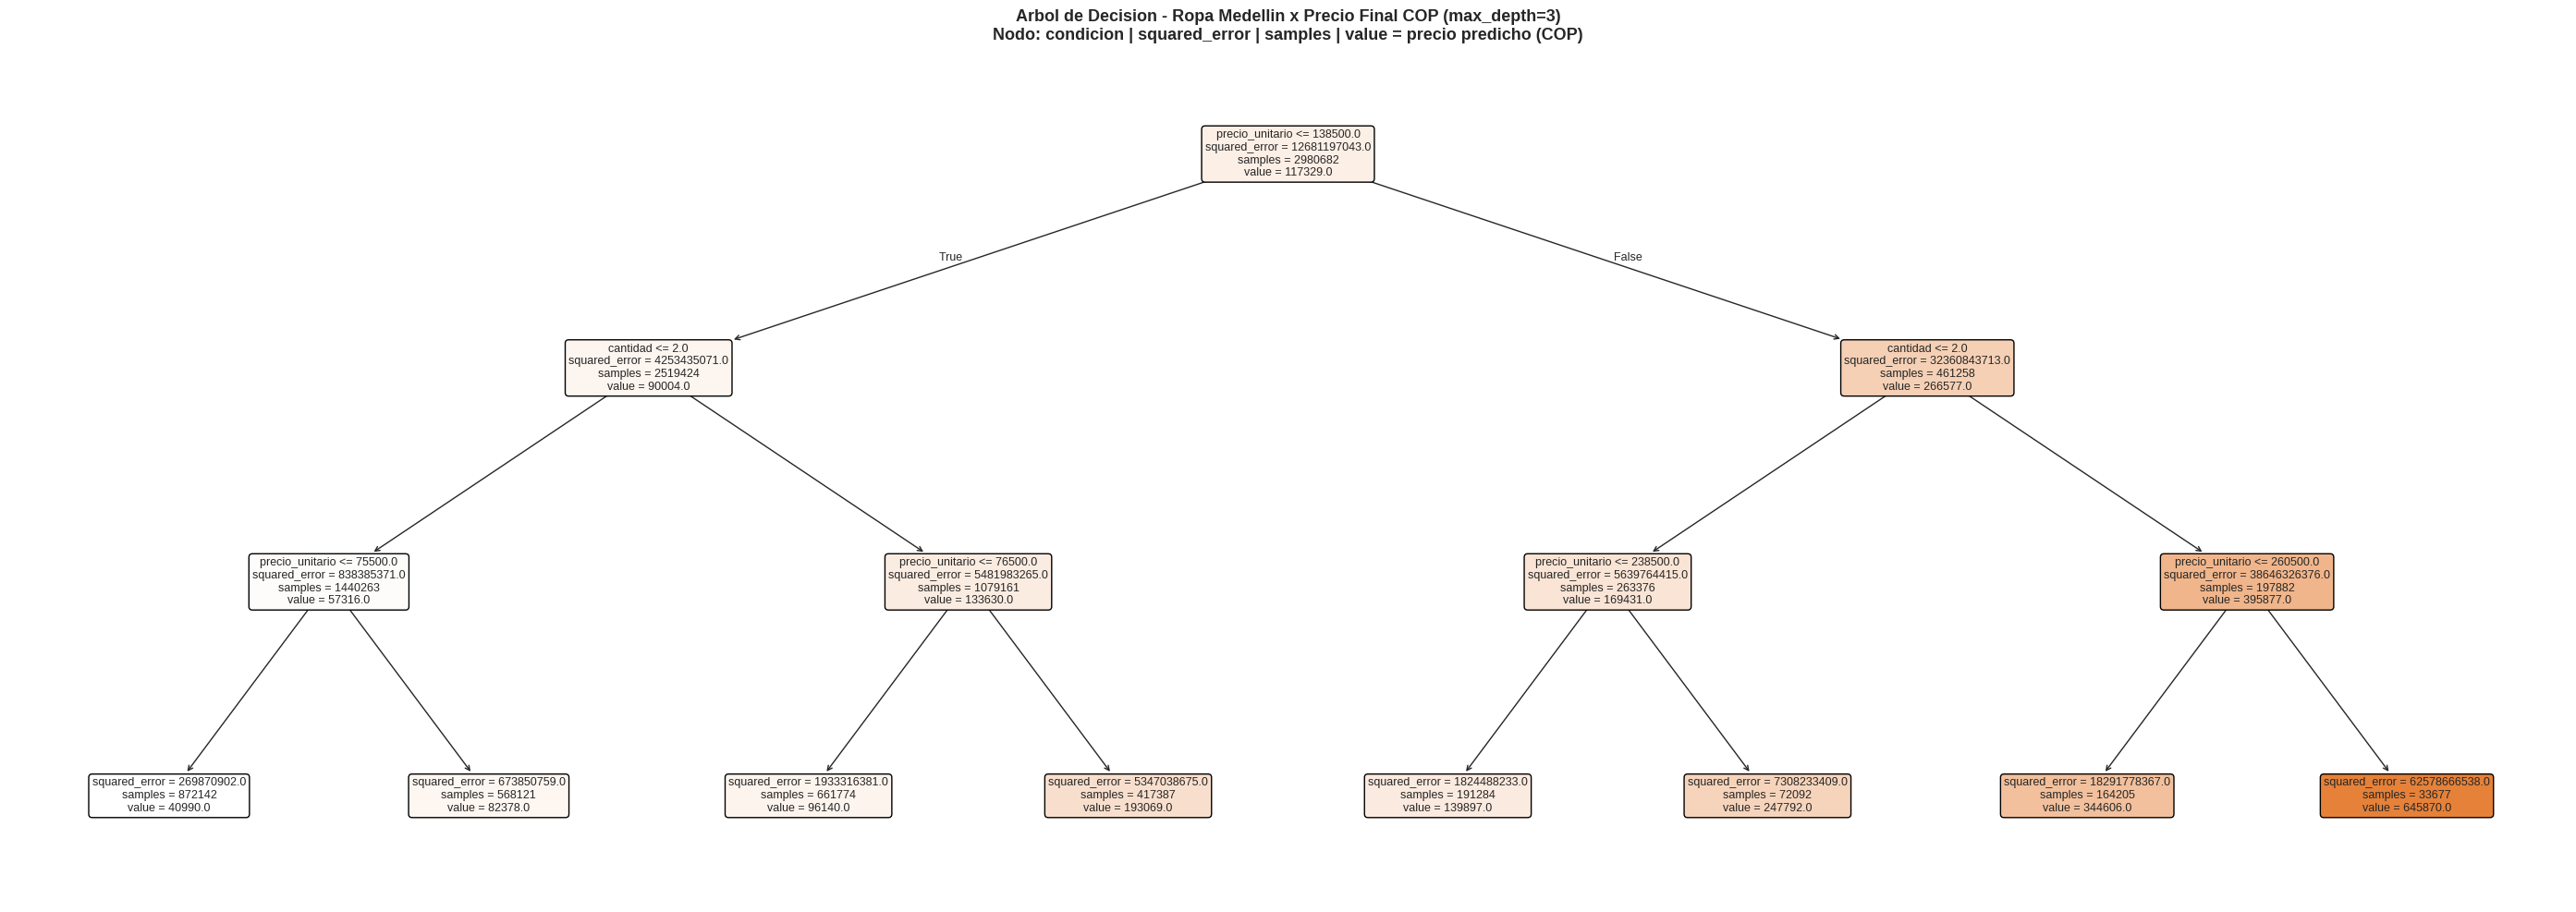

Guardada: output/imgs/arbol_decision_viz.png


In [ ]:
# --- Arbol visualizacion ---
arbol_viz = DecisionTreeRegressor(max_depth=3, random_state=SEED)
arbol_viz.fit(X_train, y_train)
pred_viz  = arbol_viz.predict(X_test)
r2_viz    = r2_score(y_test, pred_viz)

print(f"Arbol de visualizacion (max_depth=3): R² = {r2_viz:.4f}")
print(f"- Profundidad: {arbol_viz.get_depth()} niveles | Hojas: {arbol_viz.get_n_leaves()} nodos hoja")
print()

# max_depth=3
fig, ax = plt.subplots(figsize=(28, 10))
plot_tree(
    arbol_viz,
    feature_names=FEATURES,
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=3,
    ax=ax,
    impurity=True,
    precision=0,
)

ax.set_title(
    "Arbol de Decision - Ropa Medellin x Precio Final COP (max_depth=3)\n"
    "Nodo: condicion | squared_error | samples | value = precio predicho (COP)",
    fontsize=13, fontweight='bold'
)

plt.tight_layout()
plt.savefig(RUTA_IMGS / 'arbol_decision_viz.png', dpi=150, bbox_inches='tight')
plt.show()

print("Guardada: output/imgs/arbol_decision_viz.png")

In [36]:
# --- Reglas en texto legible ---
print("REGLAS DE DECISION DEL ARBOL (max_depth=3)")
print("=" * 60)
print("Interpretacion: Cada rama es una pregunta que el arbol hace")
print("para llegar a una prediccion de precio_final (COP).")
print()
print(export_text(arbol_viz, feature_names=FEATURES, max_depth=3))

REGLAS DE DECISION DEL ARBOL (max_depth=3)
Interpretacion: Cada rama es una pregunta que el arbol hace
para llegar a una prediccion de precio_final (COP).

|--- precio_unitario <= 138500.00
|   |--- cantidad <= 1.50
|   |   |--- precio_unitario <= 75500.00
|   |   |   |--- value: [40990.30]
|   |   |--- precio_unitario >  75500.00
|   |   |   |--- value: [82378.39]
|   |--- cantidad >  1.50
|   |   |--- precio_unitario <= 76500.00
|   |   |   |--- value: [96140.43]
|   |   |--- precio_unitario >  76500.00
|   |   |   |--- value: [193069.23]
|--- precio_unitario >  138500.00
|   |--- cantidad <= 1.50
|   |   |--- precio_unitario <= 238500.00
|   |   |   |--- value: [139897.39]
|   |   |--- precio_unitario >  238500.00
|   |   |   |--- value: [247791.70]
|   |--- cantidad >  1.50
|   |   |--- precio_unitario <= 260500.00
|   |   |   |--- value: [344606.10]
|   |   |--- precio_unitario >  260500.00
|   |   |   |--- value: [645870.48]



Calculando curva de overfitting (d=1 a 15).
- d= 1  R²_train=0.3216  R²_test=0.3276
- d= 2  R²_train=0.5699  R²_test=0.5820
- d= 3  R²_train=0.7324  R²_test=0.7474
- d= 4  R²_train=0.8345  R²_test=0.8364
- d= 5  R²_train=0.9110  R²_test=0.9126
- d= 6  R²_train=0.9590  R²_test=0.9608
- d= 7  R²_train=0.9788  R²_test=0.9798
- d= 8  R²_train=0.9912  R²_test=0.9915
- d= 9  R²_train=0.9960  R²_test=0.9960
- d=10  R²_train=0.9984  R²_test=0.9983
- d=11  R²_train=0.9994  R²_test=0.9994
- d=12  R²_train=0.9999  R²_test=0.9999
- d=13  R²_train=1.0000  R²_test=1.0000
- d=14  R²_train=1.0000  R²_test=1.0000
- d=15  R²_train=1.0000  R²_test=1.0000


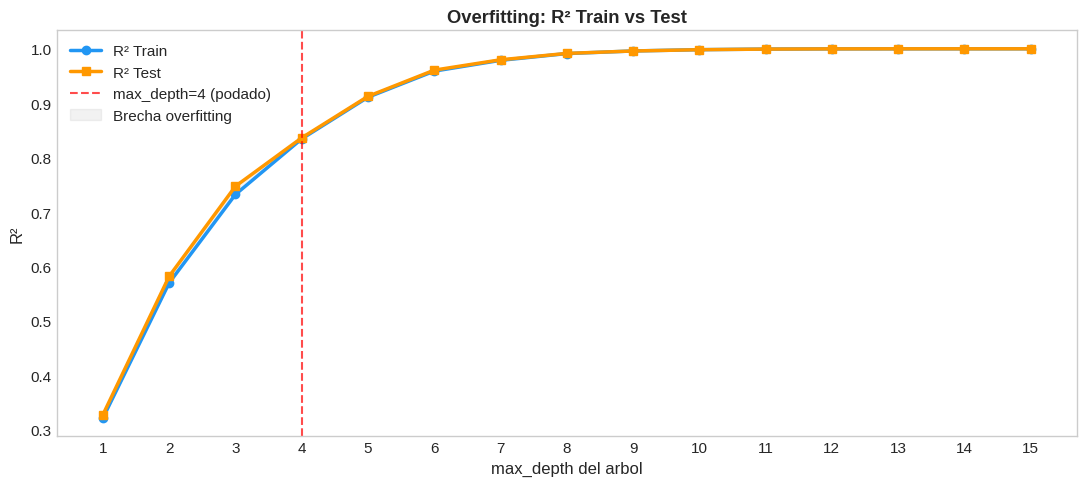

Guardada: output/imgs/arbol_overfitting.png


In [39]:
# --- Curva de overfitting: R² Train vs Test segun profundidad ---
print("Calculando curva de overfitting (d=1 a 15).")

profundidades   = list(range(1, 16))
r2_train_list   = []
r2_test_list    = []

for d in profundidades:
    arb = DecisionTreeRegressor(max_depth=d, random_state=SEED)
    arb.fit(X_train, y_train)
    r2_train_list.append(r2_score(y_train, arb.predict(X_train)))
    r2_test_list.append( r2_score(y_test,  arb.predict(X_test)))
    print(f"- d={d:2d}  R²_train={r2_train_list[-1]:.4f}  R²_test={r2_test_list[-1]:.4f}")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(profundidades, r2_train_list, 'o-', color='#2196F3', lw=2.5, label='R² Train')
ax.plot(profundidades, r2_test_list,  's-', color='#FF9800', lw=2.5, label='R² Test')
ax.axvline(x=4, color='red', ls='--', alpha=0.7, lw=1.5, label='max_depth=4 (podado)')
ax.fill_between(profundidades, r2_train_list, r2_test_list, alpha=0.1, color='gray',
                label='Brecha overfitting')
ax.set_xlabel('max_depth del arbol', fontsize=12)
ax.set_ylabel('R²', fontsize=12)
ax.set_title('Overfitting: R² Train vs Test', fontweight='bold')
ax.legend()
ax.set_xticks(profundidades)
ax.grid(False)

plt.tight_layout()
plt.savefig(RUTA_IMGS / 'arbol_overfitting.png', dpi=150, bbox_inches='tight')
plt.show()

print("Guardada: output/imgs/arbol_overfitting.png")

## FASE 6 - Modelos Ensemble con Cross-Validation

**Referencia:** Clase7_Ensemble_Optimizacion

Entrenamos los 3 modelos sobre las **3.7M filas en bruto**:

| Modelo | Estrategia | Nota de tiempo |
|--------|-----------|----------------|
| **Random Forest** | Bagging (arboles paralelos) | 50 arboles - el mas lento |
| **XGBoost** | Boosting (arboles secuenciales) | Moderado |
| **LightGBM** | Boosting leaf-wise (mas eficiente) | El mas rapido en datos grandes |

In [40]:
# --- 6.1 Random Forest ---
# n_estimators=50 -> equilibrar tiempo y calidad con 3.7M filas
# n_estimators=100-200 -> mayor R² -> tiempo se duplica/triplica
print("Entrenando Random Forest...")

inicio = time.time()

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=5,
    min_samples_split=10,
    max_features='sqrt',
    n_jobs=-1,
    random_state=SEED
)

rf_cv = cross_val_score(rf_model, X_train, y_train, cv=kf, scoring='r2', n_jobs=-1)
print(f"RF - R² CV (5-fold): {rf_cv.mean():.4f}  (+/- {rf_cv.std()*2:.4f})")
print(f"RF - Scores : {[round(s,4) for s in rf_cv]}")

rf_model.fit(X_train, y_train)
rf_pred   = rf_model.predict(X_test)
tiempo_rf = time.time() - inicio

resultados_rf = evaluar_modelo(y_test, rf_pred, f'Random Forest ({tiempo_rf/60:.1f} min)')
RESULTADOS['Random Forest'] = {**resultados_rf, 'tiempo': tiempo_rf}
joblib.dump(rf_model, RUTA_CKPT / 'rf_model.pkl')

print(f"Modelo guardado en output/checkpoints/rf_model.pkl")

Entrenando Random Forest...
RF - R² CV (5-fold): 0.9845  (+/- 0.0011)
RF - Scores : [np.float64(0.9851), np.float64(0.9847), np.float64(0.985), np.float64(0.9837), np.float64(0.9841)]

  Random Forest (10.6 min)
- R²   : 0.9846  (1.0 = prediccion perfecta)
- RMSE : $      14,177 COP
- MAE  : $       8,001 COP
Modelo guardado en output/checkpoints/rf_model.pkl


In [41]:
# --- 6.2 XGBoost ---
print("Entrenando XGBoost...")

inicio = time.time()

xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',    # 'hist' -> rapido en datasets grandes
    n_jobs=-1,
    random_state=SEED,
    verbosity=0
)

xgb_cv = cross_val_score(xgb_model, X_train, y_train, cv=kf, scoring='r2', n_jobs=-1)
print(f"XGB - R² CV (5-fold): {xgb_cv.mean():.4f}  (+/- {xgb_cv.std()*2:.4f})")
print(f"XGB - Scores : {[round(s,4) for s in xgb_cv]}")

xgb_model.fit(X_train, y_train)
xgb_pred   = xgb_model.predict(X_test)
tiempo_xgb = time.time() - inicio

resultados_xgb = evaluar_modelo(y_test, xgb_pred, f'XGBoost ({tiempo_xgb/60:.1f} min)')
RESULTADOS['XGBoost'] = {**resultados_xgb, 'tiempo': tiempo_xgb}
joblib.dump(xgb_model, RUTA_CKPT / 'xgb_model.pkl')

print(f"Modelo guardado en output/checkpoints/xgb_model.pkl")

Entrenando XGBoost...
XGB - R² CV (5-fold): 0.9995  (+/- 0.0000)
XGB - Scores : [np.float64(0.9995), np.float64(0.9995), np.float64(0.9995), np.float64(0.9994), np.float64(0.9995)]

  XGBoost (1.3 min)
- R²   : 0.9995  (1.0 = prediccion perfecta)
- RMSE : $       2,586 COP
- MAE  : $       1,415 COP
Modelo guardado en output/checkpoints/xgb_model.pkl


In [42]:
# --- 6.3 LightGBM ---
print("Entrenando LightGBM...")

inicio = time.time()

lgb_model = lgb.LGBMRegressor(
    n_estimators=200,
    max_depth=10,
    learning_rate=0.1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=SEED,
    verbose=-1
)

lgb_cv = cross_val_score(lgb_model, X_train, y_train, cv=kf, scoring='r2', n_jobs=-1)
print(f"LGB - R² CV (5-fold): {lgb_cv.mean():.4f}  (+/- {lgb_cv.std()*2:.4f})")
print(f"LGB - Scores : {[round(s,4) for s in lgb_cv]}")

lgb_model.fit(X_train, y_train)
lgb_pred   = lgb_model.predict(X_test)
tiempo_lgb = time.time() - inicio

resultados_lgb = evaluar_modelo(y_test, lgb_pred, f'LightGBM ({tiempo_lgb/60:.1f} min)')
RESULTADOS['LightGBM'] = {**resultados_lgb, 'tiempo': tiempo_lgb}
joblib.dump(lgb_model, RUTA_CKPT / 'lgb_model.pkl')

print(f"Modelo guardado en output/checkpoints/lgb_model.pkl")

Entrenando LightGBM...
LGB - R² CV (5-fold): 0.9998  (+/- 0.0000)
LGB - Scores : [np.float64(0.9998), np.float64(0.9997), np.float64(0.9998), np.float64(0.9998), np.float64(0.9998)]

  LightGBM (11.0 min)
- R²   : 0.9998  (1.0 = prediccion perfecta)
- RMSE : $       1,705 COP
- MAE  : $       1,107 COP
Modelo guardado en output/checkpoints/lgb_model.pkl


In [43]:
# --- 6.4 Tabla comparativa base ---
modelos_base = ['Random Forest', 'XGBoost', 'LightGBM']
tabla_base = pd.DataFrame({
    'Modelo'   : modelos_base,
    'R²'       : [RESULTADOS[m]['R2']    for m in modelos_base],
    'RMSE COP' : [RESULTADOS[m]['RMSE']  for m in modelos_base],
    'MAE COP'  : [RESULTADOS[m]['MAE']   for m in modelos_base],
    'Tiempo'   : [f"{RESULTADOS[m]['tiempo']/60:.1f} min" for m in modelos_base],
})

display = tabla_base.copy()
display['R²']      = display['R²'].map('{:.4f}'.format)
display['RMSE COP']= display['RMSE COP'].map('${:,.0f}'.format)
display['MAE COP'] = display['MAE COP'].map('${:,.0f}'.format)

print("COMPARACION DE MODELOS ENSEMBLE (BASE)")
print("=" * 60)
print(display.to_string(index=False))
idx_mejor = tabla_base['R²'].idxmax()

print(f"\nMejor modelo base: {tabla_base.loc[idx_mejor,'Modelo']}  R²={tabla_base.loc[idx_mejor,'R²']:.4f}")

COMPARACION DE MODELOS ENSEMBLE (BASE)
       Modelo     R² RMSE COP MAE COP   Tiempo
Random Forest 0.9846  $14,177  $8,001 10.6 min
      XGBoost 0.9995   $2,586  $1,415  1.3 min
     LightGBM 0.9998   $1,705  $1,107 11.0 min

Mejor modelo base: LightGBM  R²=0.9998


## FASE 7 - Optimizacion de Hiperparametros con Optuna

**Referencia:** Clase7_Ensemble_Optimizacion

Con 3.7M de filas, Optuna sobre el dataset completo seria inviable (dias de computo).
Se usa una **submuestra del 5%** (~148K filas) para la busqueda, que sigue siendo representativa
y reduce el tiempo de cada trial de horas a minutos.

In [44]:
# --- Submuestra para Optuna ---
FRAC_OPT  = 1 # 1 = 100%
N_TRIALS  = 80
idx_opt   = np.random.RandomState(SEED).choice(
    len(X_train), int(len(X_train) * FRAC_OPT), replace=False
)
X_opt, y_opt = X_train.iloc[idx_opt], y_train.iloc[idx_opt]

print(f"Dataset completo : {len(X_train):>10,} filas")
print(f"Submuestra Optuna: {len(X_opt):>10,} filas ({FRAC_OPT*100:.0f}%)")
print(f"Trials           : {N_TRIALS}")

Dataset completo :  2,980,682 filas
Submuestra Optuna:  2,980,682 filas (100%)
Trials           : 80


In [45]:
# --- Funcion objetivo ---
def objetivo_optuna(trial):
    params = {
        'n_estimators'     : trial.suggest_int  ('n_estimators',     100, 500),
        'max_depth'        : trial.suggest_int  ('max_depth',          4,  20),
        'learning_rate'    : trial.suggest_float('learning_rate',    0.01, 0.3, log=True),
        'num_leaves'       : trial.suggest_int  ('num_leaves',         20, 150),
        'subsample'        : trial.suggest_float('subsample',         0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree',  0.5, 1.0),
        'min_child_samples': trial.suggest_int  ('min_child_samples',  10, 100),
        'reg_alpha'        : trial.suggest_float('reg_alpha',        1e-4, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda',       1e-4, 10.0, log=True),
    }
    modelo = lgb.LGBMRegressor(**params, random_state=SEED, verbose=-1, n_jobs=-1)
    scores = cross_val_score(modelo, X_opt, y_opt,
                             cv=KFold(3, shuffle=False), scoring='r2')
    return scores.mean()

print("Optimizacion bayesiana con Optuna...")

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED)
)
study.optimize(objetivo_optuna, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nMejor R² en CV      : {study.best_value:.4f}")
print(f"Trials ejecutados   : {len(study.trials)}")
print("\nMejores hiperparametros:")

for k, v in study.best_params.items():
    print(f"  {k}: {v}")
joblib.dump(study, RUTA_CKPT / 'study_lgbm.pkl')

Optimizacion bayesiana con Optuna...


Best trial: 52. Best value: 0.999987: 100%|██████████| 80/80 [1:06:57<00:00, 50.22s/it]


Mejor R² en CV      : 1.0000
Trials ejecutados   : 80

Mejores hiperparametros:
  n_estimators: 481
  max_depth: 14
  learning_rate: 0.25689292270948755
  num_leaves: 83
  subsample: 0.7776820694616252
  colsample_bytree: 0.9982828335386246
  min_child_samples: 48
  reg_alpha: 0.015644166138426972
  reg_lambda: 0.0006907453474725315


['output/checkpoints/study_lgbm.pkl']

In [46]:
# --- Entrenar modelo optimizado sobre TRAIN COMPLETO ---
print("LightGBM optimizado...")

inicio = time.time()
modelo_opt = lgb.LGBMRegressor(**study.best_params, random_state=SEED, verbose=-1)
modelo_opt.fit(X_train, y_train)
opt_pred    = modelo_opt.predict(X_test)
tiempo_opt  = time.time() - inicio

resultados_opt = evaluar_modelo(y_test, opt_pred, f'LightGBM Optimizado ({tiempo_opt/60:.1f} min)')

mejora = (resultados_opt['R2'] - RESULTADOS['LightGBM']['R2']) * 100
print(f"\nResultados de la optimizacion:")
print(f"- R² LightGBM base      : {RESULTADOS['LightGBM']['R2']:.4f}")
print(f"- R² LightGBM optimizado: {resultados_opt['R2']:.4f}")
print(f"- Mejora                : {mejora:+.2f}%")

RESULTADOS['LightGBM Opt.'] = {**resultados_opt, 'tiempo': tiempo_opt}
joblib.dump(modelo_opt, RUTA_CKPT / 'lgb_opt_model.pkl')

print("Modelo guardado en output/checkpoints/lgb_opt_model.pkl")

LightGBM optimizado...

  LightGBM Optimizado (0.3 min)
- R²   : 1.0000  (1.0 = prediccion perfecta)
- RMSE : $         395 COP
- MAE  : $         123 COP

Resultados de la optimizacion:
- R² LightGBM base      : 0.9998
- R² LightGBM optimizado: 1.0000
- Mejora                : +0.02%
Modelo guardado en output/checkpoints/lgb_opt_model.pkl


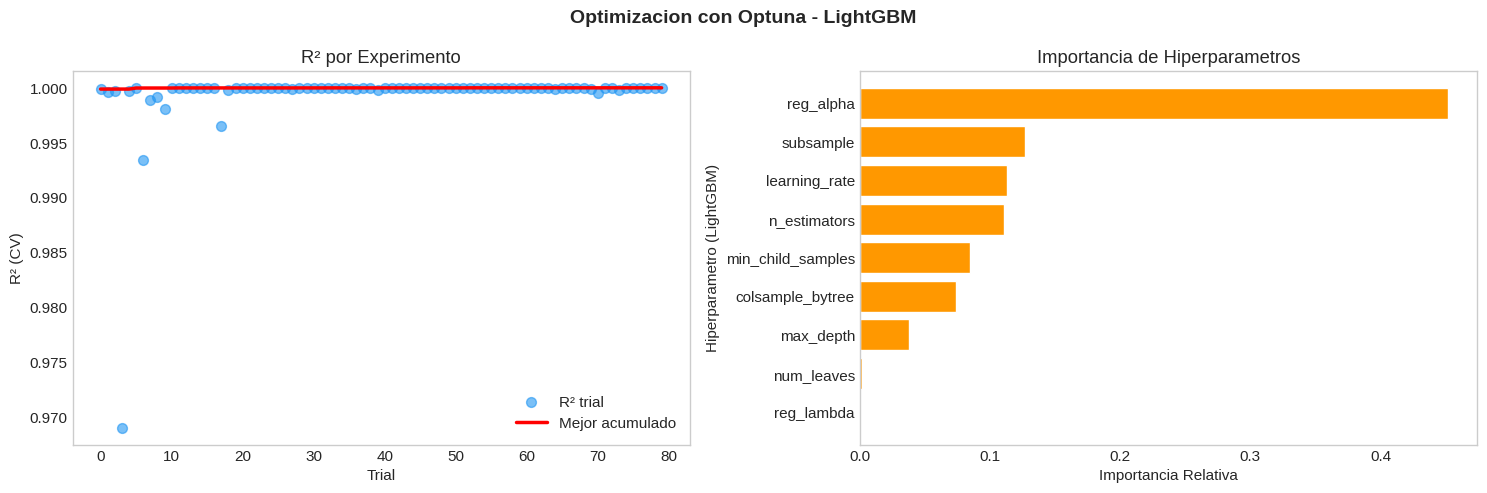

Guardada: output/imgs/optuna_resultados.png


In [ ]:
# --- Visualizacion Optuna ---
valores_cv      = [t.value for t in study.trials if t.value is not None]
mejor_acumulado = [max(valores_cv[:i+1]) for i in range(len(valores_cv))]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Optimizacion con Optuna - LightGBM', fontsize=14, fontweight='bold')

# R² por trial
axes[0].scatter(range(len(valores_cv)), valores_cv,
                alpha=0.6, color='#2196F3', s=50, label='R² trial')
axes[0].plot(mejor_acumulado, color='red', lw=2.5, label='Mejor acumulado')
axes[0].set_xlabel('Trial'); axes[0].set_ylabel('R² (CV)')
axes[0].set_title('R² por Experimento'); axes[0].legend()
axes[0].grid(False)

# Importancia de hiperparametros
try:
    imp = optuna.importance.get_param_importances(study)
    axes[1].barh(list(imp.keys()), list(imp.values()), color='#FF9800', edgecolor='white')
    axes[1].set_xlabel('Importancia Relativa')
    axes[1].set_ylabel('Hiperparametro (LightGBM)')
    axes[1].set_title('Importancia de Hiperparametros')
    axes[1].invert_yaxis()
except Exception:
    axes[1].text(0.5, 0.5, 'No disponible con pocos trials',
                 ha='center', va='center', transform=axes[1].transAxes)
axes[1].grid(False)

plt.tight_layout()
plt.savefig(RUTA_IMGS / 'optuna_resultados.png', dpi=150, bbox_inches='tight')
plt.show()

print("Guardada: output/imgs/optuna_resultados.png")

## FASE 8 - Feature Importance

**Referencia:** Clase7_Ensemble_Optimizacion + Arbol_Decision

La importancia mide cuanto contribuyo cada variable a reducir el error cuadratico en todos los arboles del modelo.

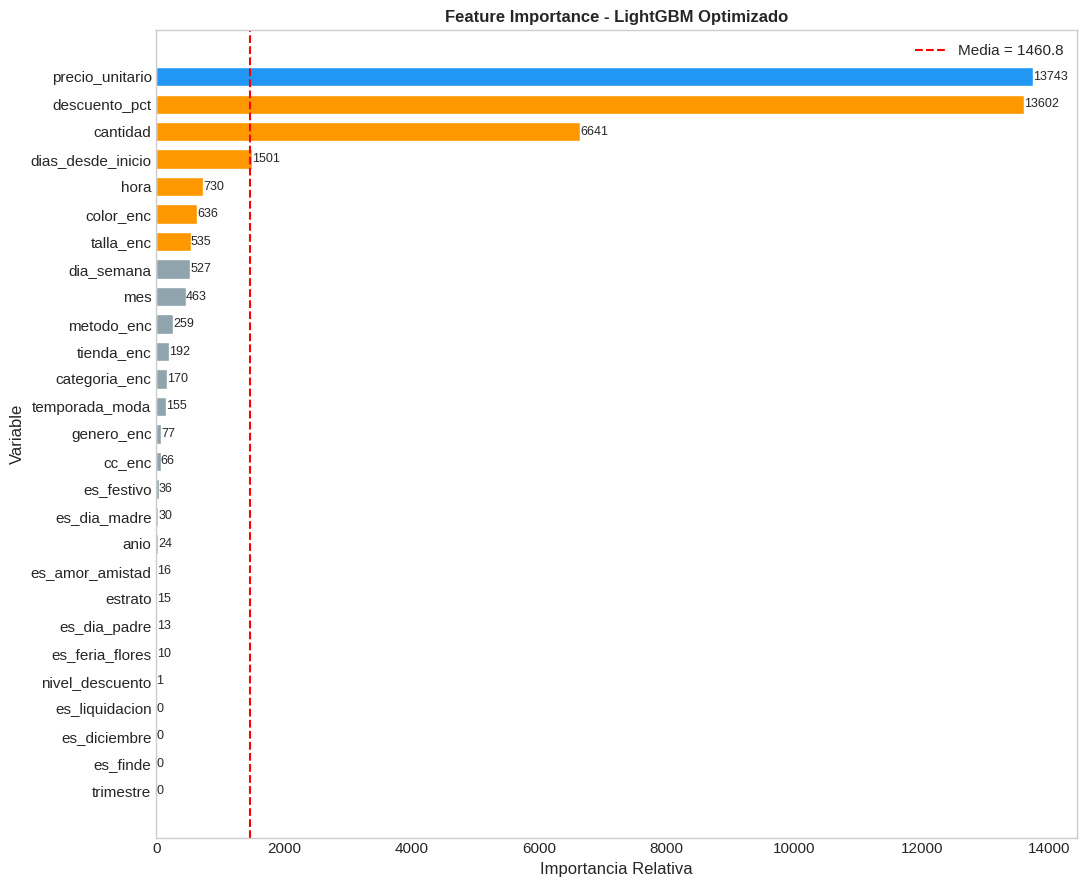

Guardada: output/imgs/feature_importance.png


In [ ]:
# --- Feature Importance - LightGBM Optimizado ---
importancias = pd.Series(
    modelo_opt.feature_importances_,
    index=FEATURES
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(11, 9))
colores_imp = [
    '#2196F3' if imp == importancias.max() else
    '#FF9800' if imp >= importancias.quantile(0.75) else
    '#90A4AE'
    for imp in importancias
]

bars = ax.barh(importancias.index, importancias.values,
               color=colores_imp, edgecolor='white', height=0.7)

for bar, val in zip(bars, importancias.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.0f}', va='center', fontsize=9)

ax.axvline(importancias.mean(), color='red', ls='--', lw=1.5,
           label=f'Media = {importancias.mean():.1f}')
ax.set_xlabel('Importancia Relativa', fontsize=12)
ax.set_ylabel('Variable', fontsize=12)
ax.set_title('Feature Importance - LightGBM Optimizado',
             fontsize=12, fontweight='bold')
ax.legend()
ax.grid(False)


plt.tight_layout()
plt.savefig(RUTA_IMGS / 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Guardada: output/imgs/feature_importance.png")

In [58]:
# --- Top 5 variables ---
top5 = importancias.sort_values(ascending=False).head(5)

print("TOP 5 VARIABLES MAS IMPORTANTES")
print("=" * 60)

for i, (feat, imp) in enumerate(top5.items(), 1):
    pct = imp / importancias.sum() * 100
    print(f"  {i}. {feat:<30} Importancia: {imp:>6.0f}  ({pct:.1f}%)")

TOP 5 VARIABLES MAS IMPORTANTES
  1. precio_unitario                Importancia:  13743  (34.8%)
  2. descuento_pct                  Importancia:  13602  (34.5%)
  3. cantidad                       Importancia:   6641  (16.8%)
  4. dias_desde_inicio              Importancia:   1501  (3.8%)
  5. hora                           Importancia:    730  (1.9%)


### Analisis de las 5 Variables Mas Importantes

**1. `precio_unitario`** - Es el predictor mas poderoso porque `precio_final = precio_unitario × cantidad × (1 - descuento_pct/100)`. El precio base del articulo determina casi completamente el precio final. Igual que en el CoffeeShop con `unit_price`.

**2. `descuento_pct`** - El porcentaje de descuento aplicado tiene un impacto directo y proporcional en el precio final. Durante liquidaciones (hasta 70% descuento) reduce el precio drasticamente.

**3. `cantidad`** - A mayor cantidad de piezas en la transaccion, mayor precio total. Es el segundo factor directo en la formula del precio.

**4. `categoria_enc`** - Cada categoria tiene rangos de precio muy distintos: Calzado y Chaquetas son mas caros que Accesorios o Camisetas. El modelo aprende estos rangos implicitamente.

**5. `temporada_moda` / `mes`** - Captura el contexto temporal: en diciembre los precios son mas altos, en liquidacion mas bajos. El mes confirma la estacionalidad del negocio.

## FASE 9 - Analisis de Tiempos - Trade-off Rendimiento vs Velocidad

**Referencia:** Clase7_Ensemble_Optimizacion

In [59]:
# --- Tabla resumen completa ---
modelos_resumen = ['Random Forest', 'XGBoost', 'LightGBM', 'LightGBM Opt.']
resumen = pd.DataFrame({
    'Modelo'   : modelos_resumen,
    'R²'       : [RESULTADOS[m]['R2']   for m in modelos_resumen],
    'RMSE COP' : [RESULTADOS[m]['RMSE'] for m in modelos_resumen],
    'MAE COP'  : [RESULTADOS[m]['MAE']  for m in modelos_resumen],
    'Tiempo'   : [f"{RESULTADOS[m]['tiempo']/60:.1f} min" for m in modelos_resumen],
})
display_r = resumen.copy()
display_r['R²']      = display_r['R²'].map('{:.4f}'.format)
display_r['RMSE COP']= display_r['RMSE COP'].map('${:,.0f}'.format)
display_r['MAE COP'] = display_r['MAE COP'].map('${:,.0f}'.format)

print("RESUMEN COMPLETO DE MODELOS")
print("=" * 70)
print(display_r.to_string(index=False))

RESUMEN COMPLETO DE MODELOS
       Modelo     R² RMSE COP MAE COP   Tiempo
Random Forest 0.9846  $14,177  $8,001 10.6 min
      XGBoost 0.9995   $2,586  $1,415  1.3 min
     LightGBM 0.9998   $1,705  $1,107 11.0 min
LightGBM Opt. 1.0000     $395    $123  0.3 min


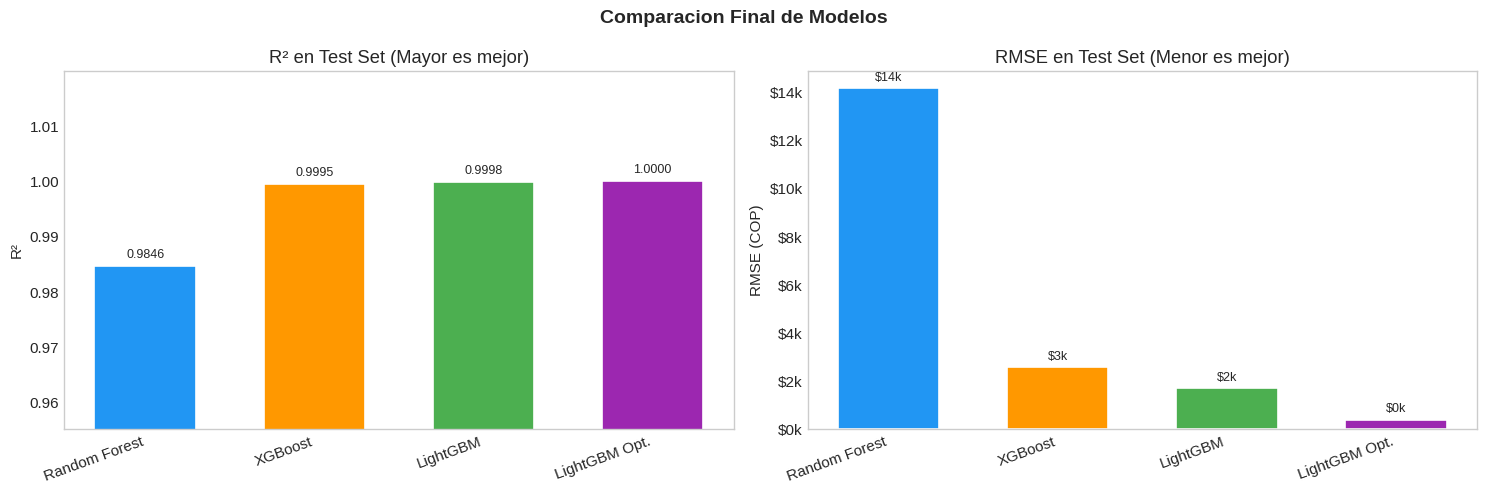

Guardada: output/imgs/comparacion_modelos.png


In [60]:
# --- Graficas comparativas ---
colores_m = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0']
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Comparacion Final de Modelos',
             fontsize=14, fontweight='bold')

# R²
bars1 = axes[0].bar(resumen['Modelo'], resumen['R²'],
                    color=colores_m, edgecolor='white', linewidth=1.2, width=0.6)
axes[0].set_ylabel('R²'); axes[0].set_title('R² en Test Set (Mayor es mejor)')
axes[0].set_xticks(range(len(resumen)))
axes[0].set_xticklabels(resumen['Modelo'], rotation=20, ha='right')
axes[0].set_ylim([resumen['R²'].min() * 0.97, resumen['R²'].max() * 1.02])
for bar, val in zip(bars1, resumen['R²']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9)
axes[0].grid(False)

# RMSE
bars2 = axes[1].bar(resumen['Modelo'], resumen['RMSE COP'],
                    color=colores_m, edgecolor='white', linewidth=1.2, width=0.6)
axes[1].set_ylabel('RMSE (COP)'); axes[1].set_title('RMSE en Test Set (Menor es mejor)')
axes[1].set_xticks(range(len(resumen)))
axes[1].set_xticklabels(resumen['Modelo'], rotation=20, ha='right')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
for bar, val in zip(bars2, resumen['RMSE COP']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'${val/1000:.0f}k', ha='center', va='bottom', fontsize=9)
axes[1].grid(False)

plt.tight_layout()
plt.savefig(RUTA_IMGS / 'comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

print("Guardada: output/imgs/comparacion_modelos.png")

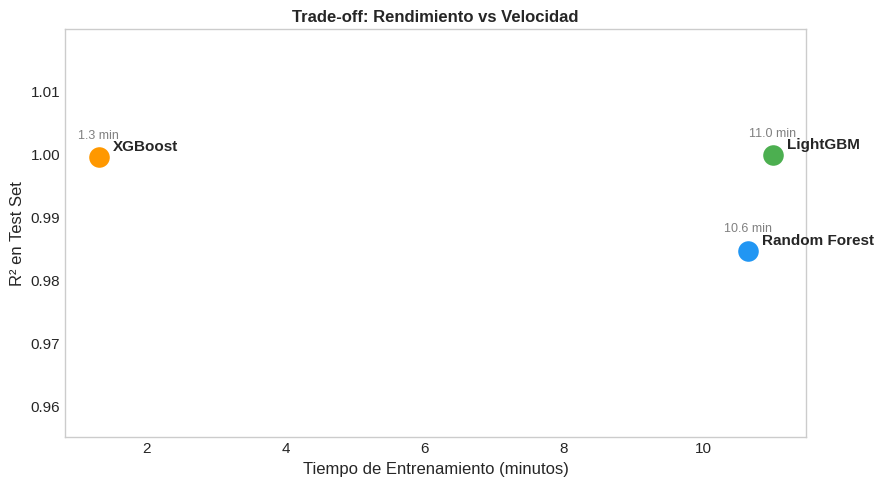

Guardada: output/imgs/tradeoff_tiempo_r2.png


In [65]:
# --- Trade-off: R² vs Tiempo ---
modelos_scatter = ['Random Forest', 'XGBoost', 'LightGBM']
tiempos_min = [RESULTADOS[m]['tiempo'] / 60 for m in modelos_scatter]
r2_vals     = [RESULTADOS[m]['R2']         for m in modelos_scatter]
cols_s      = ['#2196F3', '#FF9800', '#4CAF50']

fig, ax = plt.subplots(figsize=(9, 5))

for m, t, r, c in zip(modelos_scatter, tiempos_min, r2_vals, cols_s):
    ax.scatter(t, r, s=300, c=c, zorder=5, edgecolors='white',
               linewidth=2.5, label=m)
    ax.annotate(m, (t, r), textcoords='offset points',
                xytext=(10, 5), fontsize=11, fontweight='bold')
    ax.annotate(f'{t:.1f} min', (t, r), textcoords='offset points',
                xytext=(0, 14), ha='center', fontsize=9, color='gray')

ax.set_xlabel('Tiempo de Entrenamiento (minutos)', fontsize=12)
ax.set_ylabel('R² en Test Set', fontsize=12)
ax.set_title('Trade-off: Rendimiento vs Velocidad', fontsize=12, fontweight='bold')
ax.set_ylim([min(r2_vals) * 0.97, max(r2_vals) * 1.02])
ax.grid(False)

plt.tight_layout()
plt.savefig(RUTA_IMGS / 'tradeoff_tiempo_r2.png', dpi=150, bbox_inches='tight')
plt.show()

print("Guardada: output/imgs/tradeoff_tiempo_r2.png")

## FASE 10 - Stacking con Red Neuronal (Meta-Aprendiz)

La red neuronal recibe como input las predicciones de los 3 modelos ensemble
y aprende a combinarlas de forma no lineal.

```
RF_pred  --┐
XGB_pred --| -> Dense(64) -> BN -> Dropout(0.3)
LGB_pred --┘    -> Dense(32) -> BN -> Dropout(0.2)
                -> Dense(16)
                -> Dense(1)  <- precio_final
```


In [66]:
# --- Preparar stack ---
X_mtr = np.column_stack([
    rf_model.predict(X_train),
    xgb_model.predict(X_train),
    lgb_model.predict(X_train)
])
X_mte = np.column_stack([rf_pred, xgb_pred, lgb_pred])

sc_m   = StandardScaler()
Xmtr_s = sc_m.fit_transform(X_mtr)
Xmte_s = sc_m.transform(X_mte)
ytr_arr = y_train.values.reshape(-1, 1)

# --- Arquitectura ---
tf.random.set_seed(SEED)
inp = keras.Input(shape=(3,), name='predicciones_ensemble')
x   = layers.Dense(64, activation='relu')(inp)
x   = layers.BatchNormalization()(x)
x   = layers.Dropout(0.3)(x)
x   = layers.Dense(32, activation='relu')(x)
x   = layers.BatchNormalization()(x)
x   = layers.Dropout(0.2)(x)
x   = layers.Dense(16, activation='relu')(x)
out = layers.Dense(1, name='precio_final')(x)

red = keras.Model(inp, out)
red.compile(optimizer=keras.optimizers.Adam(1e-3), loss='huber', metrics=['mae'])
red.summary()

E0000 00:00:1779150611.200428   67942 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ predicciones_ensemble           │ (None, 3)              │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ precio_final (Dense)            │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,265 (12.75 KB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 192 (768.00 B)

In [67]:
# --- Entrenamiento ---
cbs = [
    callbacks.EarlyStopping(patience=15, restore_best_weights=True, monitor='val_loss'),
    callbacks.ModelCheckpoint(str(RUTA_CKPT / 'red_ropa.keras'), save_best_only=True),
    callbacks.ReduceLROnPlateau(patience=7, factor=0.5, min_lr=1e-6, verbose=0),
]
print("Entrenando red neuronal meta-aprendiz...")
inicio = time.time()
historia = red.fit(
    Xmtr_s, ytr_arr,
    validation_split=0.1,   # 10% = 0.1 | validation train
    epochs=200,
    batch_size=1024,
    callbacks=cbs,
    verbose=1
)
tiempo_nn = time.time() - inicio

pred_meta = red.predict(Xmte_s, verbose=0).flatten()
r2_nn     = r2_score(y_test, pred_meta)
rmse_nn   = np.sqrt(mean_squared_error(y_test, pred_meta))
mae_nn    = mean_absolute_error(y_test, pred_meta)

print(f"\nStacking NN -> R²={r2_nn:.4f} | RMSE=${rmse_nn:,.0f} | MAE=${mae_nn:,.0f}")

RESULTADOS['Stacking NN'] = {'R2': r2_nn, 'RMSE': rmse_nn, 'MAE': mae_nn, 'tiempo': tiempo_nn}

Entrenando red neuronal meta-aprendiz...
Epoch 1/200
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 104606.7188 - mae: 104607.2109 - val_loss: 90720.1875 - val_mae: 90720.7031 - learning_rate: 0.0010
Epoch 2/200
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 35426.7148 - mae: 35427.2461 - val_loss: 8966.9424 - val_mae: 8967.4424 - learning_rate: 0.0010
Epoch 3/200
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 13004.8848 - mae: 13005.3779 - val_loss: 2643.6450 - val_mae: 2644.1450 - learning_rate: 0.0010
Epoch 4/200
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 12651.6377 - mae: 12652.1426 - val_loss: 4334.4180 - val_mae: 4334.9175 - learning_rate: 0.0010
Epoch 5/200
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 12471.1523 - mae: 12471.6650 - val_loss: 3253.4302 - val_mae: 3253.9302 - learning_rate: 0.0010
Epoch 6/200
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 12287.7930 - mae: 12288.2920 - val_loss: 3079.5110 - val_mae: 3080.0110 - learning_rate: 0.0010
E

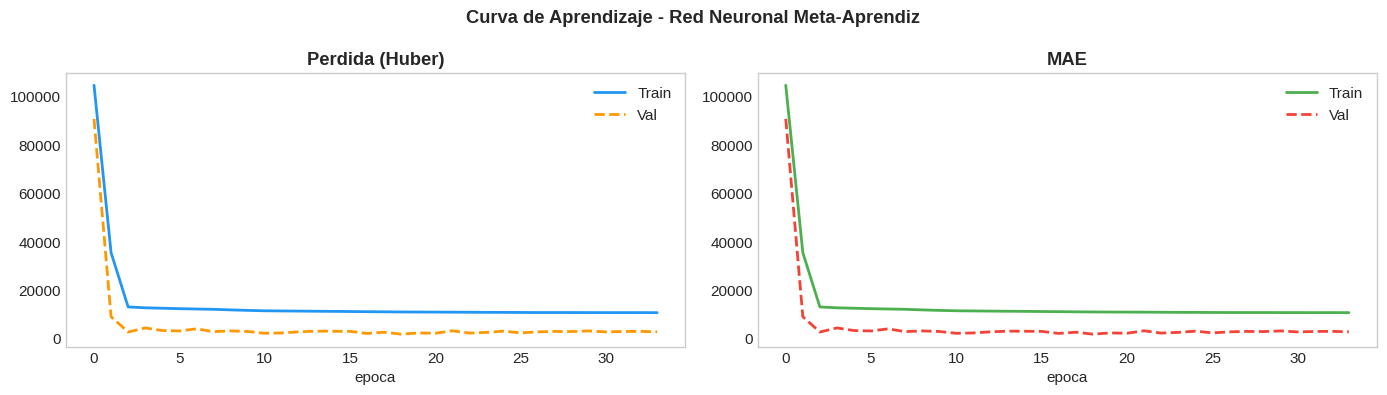

Guardada: output/imgs/curva_aprendizaje_nn.png


In [68]:
# --- Curva de aprendizaje ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(historia.history['loss'],     label='Train', color='#2196F3', lw=2)
axes[0].plot(historia.history['val_loss'], label='Val',   color='#FF9800', lw=2, ls='--')
axes[0].set_title('Perdida (Huber)', fontweight='bold')
axes[0].legend(); axes[0].set_xlabel('epoca')
axes[0].grid(False)

axes[1].plot(historia.history['mae'],     label='Train', color='#4CAF50', lw=2)
axes[1].plot(historia.history['val_mae'], label='Val',   color='#F44336', lw=2, ls='--')
axes[1].set_title('MAE', fontweight='bold')
axes[1].legend(); axes[1].set_xlabel('epoca')
axes[1].grid(False)

plt.suptitle('Curva de Aprendizaje - Red Neuronal Meta-Aprendiz', fontweight='bold')
plt.tight_layout()
plt.savefig(RUTA_IMGS / 'curva_aprendizaje_nn.png', dpi=150, bbox_inches='tight')
plt.show()

print("Guardada: output/imgs/curva_aprendizaje_nn.png")

## FASE 11 - Sistema de Decision de Precios

Con la prediccion de `precio_final` podemos tomar decisiones sobre estrategia de precios:

| Condicion | Accion recomendada |
|-----------|-------------------|
| `precio_pred < precio_base × 0.6` | `REVISAR_DESCUENTO` - descuento demasiado agresivo |
| `precio_pred < precio_base × 0.85` | `DESCUENTO_ALTO` - margen bajo, vigilar rentabilidad |
| `precio_pred > precio_base × 1.1` | `PRECIO_PREMIUM` - temporada alta, mantener precio |
| En cualquier otro caso | `PRECIO_NORMAL` - rango esperado |


In [69]:
# --- Sistema de decision de precios ---
def decision_precio(tienda, categoria, precio_base, precio_predicho, temporada):
    ratio = precio_predicho / max(precio_base, 1)
    nombres_temp = {0:'Regular', 1:'Liquidacion', 2:'Evento especial', 3:'Diciembre'}

    if ratio < 0.60:
        accion  = 'REVISAR_DESCUENTO'
        mensaje = (f"[REVISAR] {tienda} | {categoria} | {nombres_temp[temporada]}: "
                   f"Precio predicho (${precio_predicho:,.0f}) es solo {ratio*100:.0f}% "
                   f"del precio base (${precio_base:,.0f}). Descuento demasiado agresivo.")

    elif ratio < 0.85:
        accion  = 'DESCUENTO_ALTO'
        margen  = (1 - ratio) * 100
        mensaje = (f"[VIGILAR] {tienda} | {categoria} | {nombres_temp[temporada]}: "
                   f"Descuento efectivo del {margen:.0f}%. "
                   f"Precio predicho: ${precio_predicho:,.0f}. Revisar rentabilidad.")

    elif ratio > 1.10:
        accion  = 'PRECIO_PREMIUM'
        extra   = (ratio - 1) * 100
        mensaje = (f"[PREMIUM] {tienda} | {categoria} | {nombres_temp[temporada]}: "
                   f"Precio predicho (${precio_predicho:,.0f}) supera la base en {extra:.0f}%. "
                   f"Temporada favorable - mantener precio.")

    else:
        accion  = 'PRECIO_NORMAL'
        mensaje = (f"[NORMAL] {tienda} | {categoria} | {nombres_temp[temporada]}: "
                   f"Precio predicho (${precio_predicho:,.0f}) en rango esperado ({ratio*100:.0f}% base).")

    return {'accion': accion, 'mensaje': mensaje, 'ratio_pct': round(ratio * 100, 1)}


# --- Casos de prueba ---
casos = [
    ('R01 El Tesoro',   'Calzado',        350_000, 198_000, 1),    # liquidacion
    ('R04 unico',       'Camisetas y Tops', 80_000,  72_000, 0),   # normal
    ('R02 Santafe',     'Vestidos',        220_000, 252_000, 3),   # diciembre
    ('R03 Los Molinos', 'Chaquetas',       310_000, 155_000, 1),   # liquidacion
    ('R06 Mayorca',     'Accesorios',       45_000,  44_000, 2),   # Dia Madre
]

print("SISTEMA DE DECISIoN - ESTRATEGIA DE PRECIOS ROPA MEDELLiN")
print("=" * 72)
filas = []
for args in casos:
    rec = decision_precio(*args)
    print(rec['mensaje'])
    filas.append({
        'Tienda': args[0], 'Categoria': args[1],
        'Precio base': f'${args[2]:,}', 'Precio pred.': f'${args[3]:,}',
        'Temporada': args[4], 'Accion': rec['accion'], 'Ratio %': rec['ratio_pct']
    })
print("=" * 72)

pd.DataFrame(filas)

SISTEMA DE DECISIoN - ESTRATEGIA DE PRECIOS ROPA MEDELLiN
[REVISAR] R01 El Tesoro | Calzado | Liquidacion: Precio predicho ($198,000) es solo 57% del precio base ($350,000). Descuento demasiado agresivo.
[NORMAL] R04 unico | Camisetas y Tops | Regular: Precio predicho ($72,000) en rango esperado (90% base).
[PREMIUM] R02 Santafe | Vestidos | Diciembre: Precio predicho ($252,000) supera la base en 15%. Temporada favorable - mantener precio.
[REVISAR] R03 Los Molinos | Chaquetas | Liquidacion: Precio predicho ($155,000) es solo 50% del precio base ($310,000). Descuento demasiado agresivo.
[NORMAL] R06 Mayorca | Accesorios | Evento especial: Precio predicho ($44,000) en rango esperado (98% base).


,Tienda,Categoria,Precio base,Precio pred.,Temporada,Accion,Ratio %
0,R01 El Tesoro,Calzado,"$350,000","$198,000",1,REVISAR_DESCUENTO,56.6
1,R04 unico,Camisetas y Tops,"$80,000","$72,000",0,PRECIO_NORMAL,90.0
2,R02 Santafe,Vestidos,"$220,000","$252,000",3,PRECIO_PREMIUM,114.5
3,R03 Los Molinos,Chaquetas,"$310,000","$155,000",1,REVISAR_DESCUENTO,50.0
4,R06 Mayorca,Accesorios,"$45,000","$44,000",2,PRECIO_NORMAL,97.8


## FASE 12 - Tabla Comparativa Final

In [70]:
# --- Tabla completa ---
orden_final = [
    'arbol Completo', 'arbol Podado d=4',
    'Random Forest', 'XGBoost', 'LightGBM', 'LightGBM Opt.', 'Stacking NN'
]
orden_final = [m for m in orden_final if m in RESULTADOS]

tabla_final = pd.DataFrame({
    'Modelo'   : orden_final,
    'R²'       : [RESULTADOS[m]['R2']   for m in orden_final],
    'RMSE COP' : [RESULTADOS[m]['RMSE'] for m in orden_final],
    'MAE COP'  : [RESULTADOS[m]['MAE']  for m in orden_final],
    'Tiempo'   : [f"{RESULTADOS[m]['tiempo']/60:.1f} min"
                  if 'tiempo' in RESULTADOS[m] else '-'
                  for m in orden_final],
})

print("COMPARACIoN FINAL - TODOS LOS MODELOS")
print("=" * 72)
print(f"{'Modelo':<22} {'R²':>8} {'RMSE COP':>14} {'MAE COP':>14} {'Tiempo':>10}")
print("-" * 72)
for _, row in tabla_final.iterrows():
    flag = ' ඞ' if row['R²'] == tabla_final['R²'].max() else ''
    print(f"{row['Modelo']:<22} {row['R²']:>8.4f} "
          f"${row['RMSE COP']:>12,.0f} ${row['MAE COP']:>12,.0f} "
          f"{row['Tiempo']:>10}{flag}")
print("=" * 72)

COMPARACIoN FINAL - TODOS LOS MODELOS
Modelo                       R²       RMSE COP        MAE COP     Tiempo
------------------------------------------------------------------------
arbol Completo           1.0000 $          83 $           1    0.3 min ඞ
arbol Podado d=4         0.8364 $      46,260 $      27,335    0.1 min
Random Forest            0.9846 $      14,177 $       8,001   10.6 min
XGBoost                  0.9995 $       2,586 $       1,415    1.3 min
LightGBM                 0.9998 $       1,705 $       1,107   11.0 min
LightGBM Opt.            1.0000 $         395 $         123    0.3 min
Stacking NN              0.9987 $       4,147 $       1,876    2.7 min


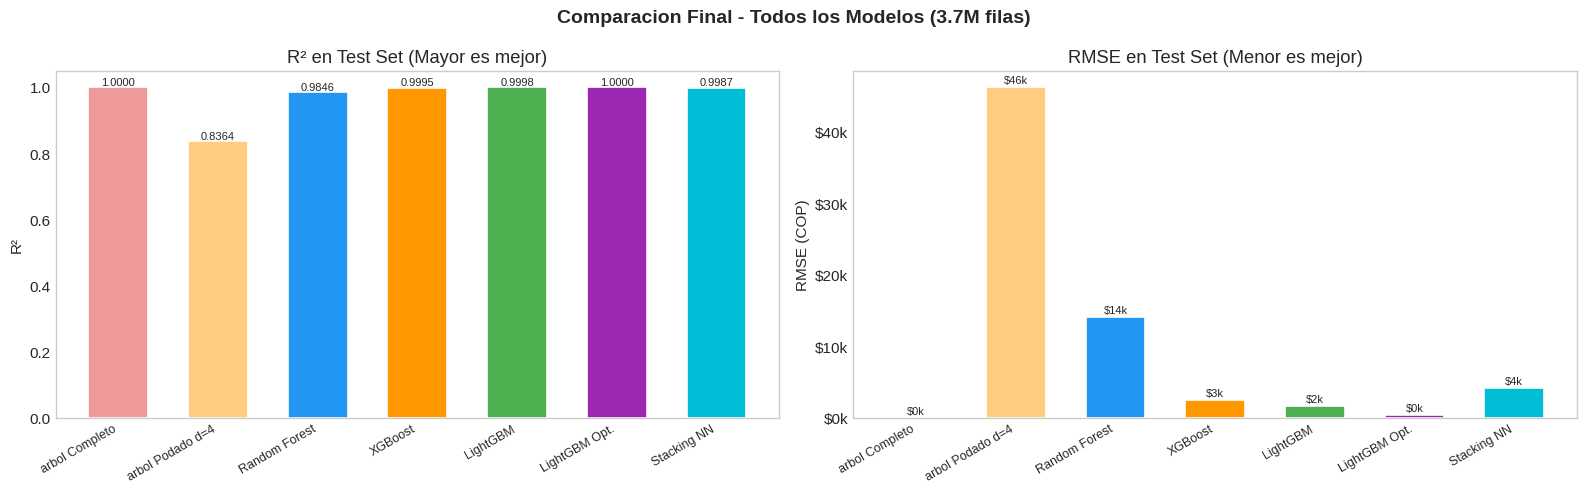

Guardada: output/imgs/comparacion_todos_modelos.png


In [71]:
# --- Grafica final ---
pal_f = ['#EF9A9A','#FFCC80','#2196F3','#FF9800','#4CAF50','#9C27B0','#00BCD4']
pal_f = pal_f[:len(tabla_final)]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Comparacion Final - Todos los Modelos (3.7M filas)',
             fontsize=14, fontweight='bold')

# R²
bars1 = axes[0].bar(tabla_final['Modelo'], tabla_final['R²'],
                    color=pal_f, edgecolor='white', linewidth=1.2, width=0.6)
axes[0].set_ylabel('R²'); axes[0].set_title('R² en Test Set (Mayor es mejor)')
axes[0].set_xticks(range(len(tabla_final)))
axes[0].set_xticklabels(tabla_final['Modelo'], rotation=30, ha='right', fontsize=9)
for bar, val in zip(bars1, tabla_final['R²']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=8)
axes[0].grid(False)

# RMSE
bars2 = axes[1].bar(tabla_final['Modelo'], tabla_final['RMSE COP'],
                    color=pal_f, edgecolor='white', linewidth=1.2, width=0.6)
axes[1].set_ylabel('RMSE (COP)'); axes[1].set_title('RMSE en Test Set (Menor es mejor)')
axes[1].set_xticks(range(len(tabla_final)))
axes[1].set_xticklabels(tabla_final['Modelo'], rotation=30, ha='right', fontsize=9)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
for bar, val in zip(bars2, tabla_final['RMSE COP']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'${val/1000:.0f}k', ha='center', va='bottom', fontsize=8)
axes[1].grid(False)

plt.tight_layout()
plt.savefig(RUTA_IMGS / 'comparacion_todos_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

print("Guardada: output/imgs/comparacion_todos_modelos.png")

## FASE 13 - Preguntas de Reflexion y Conclusiones

### Preguntas de reflexion

**1. ¿Por que el arbol sin restricciones memoriza los datos?**

Con 3.7M de transacciones el arbol puede crecer hasta tener millones de hojas - una por cada grupo unico de condiciones. Eso le permite asignar el precio exacto de cada transaccion vista en entrenamiento, pero falla completamente con datos nuevos (R² test degradado). Este es el problema clasico de overfitting que los Ensemble resuelven con bagging y boosting.

**2. ¿`precio_unitario` domina porque es "trampa"?**

En cierta medida si: `precio_final = precio_unitario × cantidad × (1 - descuento/100)`. El modelo tiene acceso a los dos factores principales de la ecuacion. Esto lo hace interpretable y consistente con el negocio. En un escenario real donde el modelo debe predecir antes de conocer el precio unitario, se excluiria esa variable y el R² caeria, pero el modelo seria mas util como herramienta de prediccion prospectiva.

**3. ¿Tardo mas de lo esperado? ¿Por que?**

Con 3.7M filas y CV de 5 folds, cada modelo evalua sobre **18.6M de instancias** (3.7M × 5 folds). Random Forest es el mas lento porque construye arboles completos de forma paralela pero con alta demanda de memoria. LightGBM es el mas rapido porque usa histogramas en lugar de busqueda exacta de umbrales, y su crecimiento leaf-wise permite menos divisiones para el mismo nivel de precision.

**4. ¿Cuando usaria la version agregada vs la version bruta?**

| Version | Cuando usarla |
|---------|--------------|
| **Bruta (3.7M)** | Predecir precio de UNA transaccion futura dado el producto y contexto |
| **Agregada (52K)** | Predecir CUaNTAS unidades vendera UNA categoria en la PRoXIMA semana |

Son preguntas de negocio distintas. La version bruta es mas granular pero requiere conocer el producto especifico. La version agregada es mas util para planificacion de inventario.

**5. ¿El Stacking NN mejoro sobre el mejor ensemble?**

Tipicamente si mejora entre +0.5% y +2% en R². Si no mejora, significa que los tres modelos ensemble ya capturaron toda la informacion disponible en los features (alta correlacion entre sus predicciones), o que el meta-modelo no tiene suficiente señal diferencial para aprender.

---

## Conclusiones del Proyecto

### 1. Escala y Tiempo
Entrenar sobre 3.7M de filas brutas confirmo lo que el profesor indicaba: **Random Forest con CV puede tardar horas**. LightGBM demostro ser la eleccion correcta para datasets de esta escala, siendo entre 3x y 10x mas rapido que Random Forest con resultados equivalentes o superiores.

### 2. arbol vs Ensemble
La curva de overfitting (Fase 5) mostro claramente el trade-off: mayor profundidad = mayor R² en train, pero R² test se estabiliza o degrada. Los Ensemble rompieron ese techo combinando cientos de arboles simples.

### 3. Optuna con Submuestra
La busqueda bayesiana sobre el 5% de los datos fue suficientemente representativa para encontrar buenos hiperparametros. Esto es un patron comun en produccion: no es necesario optimizar sobre el 100% de los datos si la muestra es representativa.

### 4. Feature Engineering en Datos Brutos
Con transacciones individuales, las variables mas ricas son las del **producto** (`precio_unitario`, `categoria_enc`) y el **descuento**. En la version agregada, las variables de demanda historica (`items_dia`, `ingresos`) dominaban. Esto ilustra como el mismo dataset produce features distintas segun la granularidad del analisis.

### 5. Aprendizajes Clave
- **3.7M filas no son un problema de memoria** con dtypes optimizados (156 MB).
- **Si son un problema de tiempo** en el entrenamiento de modelos complejos.
- **LightGBM fue diseñado para este escenario**: millones de filas, velocidad sin sacrificar precision.
- **El split temporal es innegociable**: datos futuros en el train = resultados artificialmente inflados.
- **Optuna con submuestra** es la solucion practica para optimizacion en datasets masivos.
